In [2]:
import fdfi
print(fdfi.__version__)

0.0.5


In [3]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from fdfi.explainers import FlowExplainer, Crossfitting

## Load Data And Feature Groups


In [4]:
DATA_DIR = Path("data")

DATASETS = {
    "sens50": {
        "file": DATA_DIR / "sens50_processed_dataset.csv",
        "target": "sens50",
    },
    "sens80": {
        "file": DATA_DIR / "sens80_processed_dataset.csv",
        "target": "sens80",
    },
    "ic50": {
        "file": DATA_DIR / "ic50.censored_processed_dataset.csv",
        "target": "ic50.censored",
    },
}

outcome = "sens50"

cfg = DATASETS[outcome]
filename = str(cfg["file"])

data = pd.read_csv(cfg["file"])
y = data[cfg["target"]].astype(int)
X = data.drop(columns=[cfg["target"]])

df_groups = pd.read_csv(DATA_DIR / "feature_group.csv", index_col=0).set_index("feature")
df_groups = pd.get_dummies(df_groups["group"]).groupby(df_groups.index).max().reindex(X.columns)

print(f"Dataset shape: {X.shape}")
print(f"Target variable: {outcome}")
print(f"Number of groups: {len(df_groups.columns)}")
print(f"Data loaded from: {filename}")


Dataset shape: (611, 832)
Target variable: sens50
Number of groups: 14
Data loaded from: data/sens50_processed_dataset.csv


In [5]:
print("Data preparation...")

preprocess = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    StandardScaler(),
)

X_values = preprocess.fit_transform(X)
y_values = y.values

print("Data preparation finished")
print(f"Feature matrix shape: {X_values.shape}")
print(f"Target vector shape: {y_values.shape}")
print(f"Target statistics: mean={y_values.mean():.3f}, std={y_values.std():.3f}")
print(f"Missing values - X: {np.isnan(X_values).sum()}, y: {np.isnan(y_values).sum()}")
print("After standardization:")
print(f"X mean: {X_values.mean():.3f}, std: {X_values.std():.3f}")


Data preparation...
Data preparation finished
Feature matrix shape: (611, 832)
Target vector shape: (611,)
Target statistics: mean=0.615, std=0.487
Missing values - X: 0, y: 0
After standardization:
X mean: -0.000, std: 1.000


In [6]:
clf = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=1.0,
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

clf.fit(X_values, y_values)

model_fn = lambda X_: clf.predict_proba(X_)[:, 1]

pred = model_fn(X_values)

print("Model trained")
print("Prediction mean:", pred.mean())
print("Nonzero coefficients:", np.sum(np.abs(clf.coef_.ravel()) > 1e-12))


Model trained
Prediction mean: 0.6075057118529973
Nonzero coefficients: 336


## Fit Flowmatching FDFI


In [8]:
print("Fitting FlowMatching FDFI with 5-fold cross fitting...")

n_folds = 5
nsamples_main = 20
flow_num_steps = 2000  # increased from 200; 200 steps yields H≈I (no disentanglement)

start_time = time.time()

cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

fdfi_estimator = Crossfitting(
    model=model_fn,
    data=X_values,
    explainer_class=FlowExplainer,
    cv=cv,
    y=y_values,
    nsamples=nsamples_main,
    method="cpi",
    sampling_method="resample",
    num_steps=flow_num_steps,
    random_state=42,
    verbose="final",
)

cf_results = fdfi_estimator()

dfi_time = time.time() - start_time

print(f"FlowMatching FDFI completed in {dfi_time:.2f} seconds")
print(f"DFI scores shape: {cf_results['phi_X'].shape}")

np.sum(cf_results["phi_X"]), np.sum(cf_results["phi_Z"])


Fitting FlowMatching FDFI with 5-fold cross fitting...
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=1.6909
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.098705 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000003 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=1.6933
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.098544 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000003 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=1.7068
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.099175 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000006 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=

(0.44216684658813094, 0.2051099379434802)

## Individual Feature Inference With conf_int()

In [15]:
# Individual feature-level inference from module-level conf_int().
# In v0.0.5, conf_int() returns "score" and "se".
# "se" is standard error, used for CI and hypothesis testing.

feature_names = X.columns.tolist()
n_features = len(feature_names)
alpha = 0.05

ci_X = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

ci_Z = fdfi_estimator.conf_int(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
    verbose=False,
)

dfi = ci_X["score"]
dfi_se = ci_X["se"]
dfiz = ci_Z["score"]
dfiz_se = ci_Z["se"]

dfi_scores = dfi / np.maximum(dfi_se, 1e-12)
dfiz_scores = dfiz / np.maximum(dfiz_se, 1e-12)

dfi_p_values = ci_X["pvalue"]
dfiz_p_values = ci_Z["pvalue"]

dfi_order = np.argsort(dfi_scores)[::-1]
dfiz_order = np.argsort(dfiz_scores)[::-1]

dfi_rank = np.empty(n_features, dtype=int)
dfi_rank[dfi_order] = np.arange(1, n_features + 1)

dfiz_rank = np.empty(n_features, dtype=int)
dfiz_rank[dfiz_order] = np.arange(1, n_features + 1)

results = pd.DataFrame({
    "feature": feature_names,
    "dfi": dfi,
    "dfi_se": dfi_se,
    "dfi_zscore": dfi_scores,
    "dfi_p_value": dfi_p_values,
    "dfi_ci_lower": ci_X["ci_lower"],
    "dfi_ci_upper": ci_X["ci_upper"],
    "dfi_reject_null": ci_X["reject_null"],
    "dfi_ranking": dfi_rank,
    "dfiz": dfiz,
    "dfiz_se": dfiz_se,
    "dfiz_score": dfiz_scores,
    "dfiz_p_value": dfiz_p_values,
    "dfiz_ci_lower": ci_Z["ci_lower"],
    "dfiz_ci_upper": ci_Z["ci_upper"],
    "dfiz_reject_null": ci_Z["reject_null"],
    "dfiz_ranking": dfiz_rank,
})

OUT_DIR = Path("results") / "flowmatching_case_study"
OUT_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(OUT_DIR / f"{outcome}_flowmatching_dfi_results.csv", index=False)


## Feature-Level Summary

In [18]:
print("=== X-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

print("\n=== Z-space feature summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    var_floor_c=0.1,
    var_floor_method="mixture",
    var_floor_quantile=0.95,
    margin=0.0,
    margin_method="auto",
    margin_quantile=0.95,
    alternative="two-sided",
)

=== X-space feature summary ===
Feature Importance Results
Method: Crossfitting
Number of units: 832
Significance level: 0.05
Alternative: two-sided
Margin method: mixture
Practical margin: 0.0024
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     0.0005     0.0022    -0.0039     0.0048     0.3977      
              1     0.0010     0.0022    -0.0034     0.0053     0.5307      
              2     0.0001     0.0022    -0.0043     0.0044     0.2966      
              3     0.0000     0.0022    -0.0043     0.0044     0.2933      
              4     0.0061     0.0044    -0.0024     0.0147     0.3872      
              5     0.0049     0.0033    -0.0015     0.0114     0.4343      
              6     0.0001     0.0022    -0.0043     0.0044     0.2958      
              7     0.0011   

## Group Importance

In [16]:
group_ci = fdfi_estimator.conf_int(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
    verbose=False,
)

res_df = pd.DataFrame({
    "group": group_ci["groups"],
    "importance": group_ci["score"],
    "se": group_ci["se"],
    "ci_lower": group_ci["ci_lower"],
    "ci_upper": group_ci["ci_upper"],
    "p_value": group_ci["pvalue"],
    "p_value_adj": group_ci.get("pvalue_adj", group_ci["pvalue"]),
    "reject_null": group_ci["reject_null"],
})

res_df["zscore"] = res_df["importance"] / np.maximum(res_df["se"], 1e-12)


## Group Summary Table

In [19]:
print("=== X-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="X",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)
print("\n=== Z-space group summary ===")
_ = fdfi_estimator.summary(
    alpha=0.05,
    target="Z",
    groups=df_groups,
    threshold_null=True,
    var_floor_c=0.1,
    var_floor_method="fixed",
    margin=0.0,
    margin_method="fixed",
    alternative="two-sided",
    multitest_method="bonferroni",
)


=== X-space group summary ===
Feature Importance Results
Method: Crossfitting
Number of units: 14
Significance level: 0.05
Alternative: two-sided
Multiple testing: bonferroni
Margin method: fixed
------------------------------------------------------------------------------
          Group   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig
------------------------------------------------------------------------------
          cd4bs     0.1667     0.0707     0.0281     0.3053     0.2577      
          covar     0.0931     0.0320     0.0304     0.1558     0.0506     *
      cysteines     0.0038     0.0044    -0.0047     0.0124     1.0000      
            esa     0.1214     0.0477     0.0278     0.2149     0.1538      
           geog     0.0006     0.0041    -0.0073     0.0086     1.0000      
       geometry     0.0044     0.0045    -0.0045     0.0133     1.0000      
          glyco     0.0224     0.0101     0.0027     0.0421     0.3600      
           gp41     0.0213    

## Group Mapping

In [11]:
group_mapping = pd.DataFrame({
    "group_num": range(1, 15),
    "group": [
        "vrc01", "cd4bs", "esa", "glyco", "covar", "pngs", "gp41",
        "pngs_novrc01", "subtype", "sequons", "geometry", "cysteines",
        "steric_bulk", "geog"
    ],
    "description": [
        "VRC01 binding footprint",
        "CD4 binding sites",
        "Sites with sufficient exposed surface area",
        "Sites identified as important for glycosylation",
        "Sites with residues that covary with\nthe VRC01 binding footprint",
        "Sites associated with VRC01-specific\npotential N-linked glycosylation (PNGS) effects",
        "gp41 sites important for VRC01 binding",
        "Sites for indicating N-linked glycosylation",
        "Majority virus subtypes",
        "Region-specific counts of PNGS",
        "Viral geometry",
        "Cysteine counts",
        "Steric bulk at critical locations",
        "Geographic confounders",
    ],
})


## Group Importance Plot

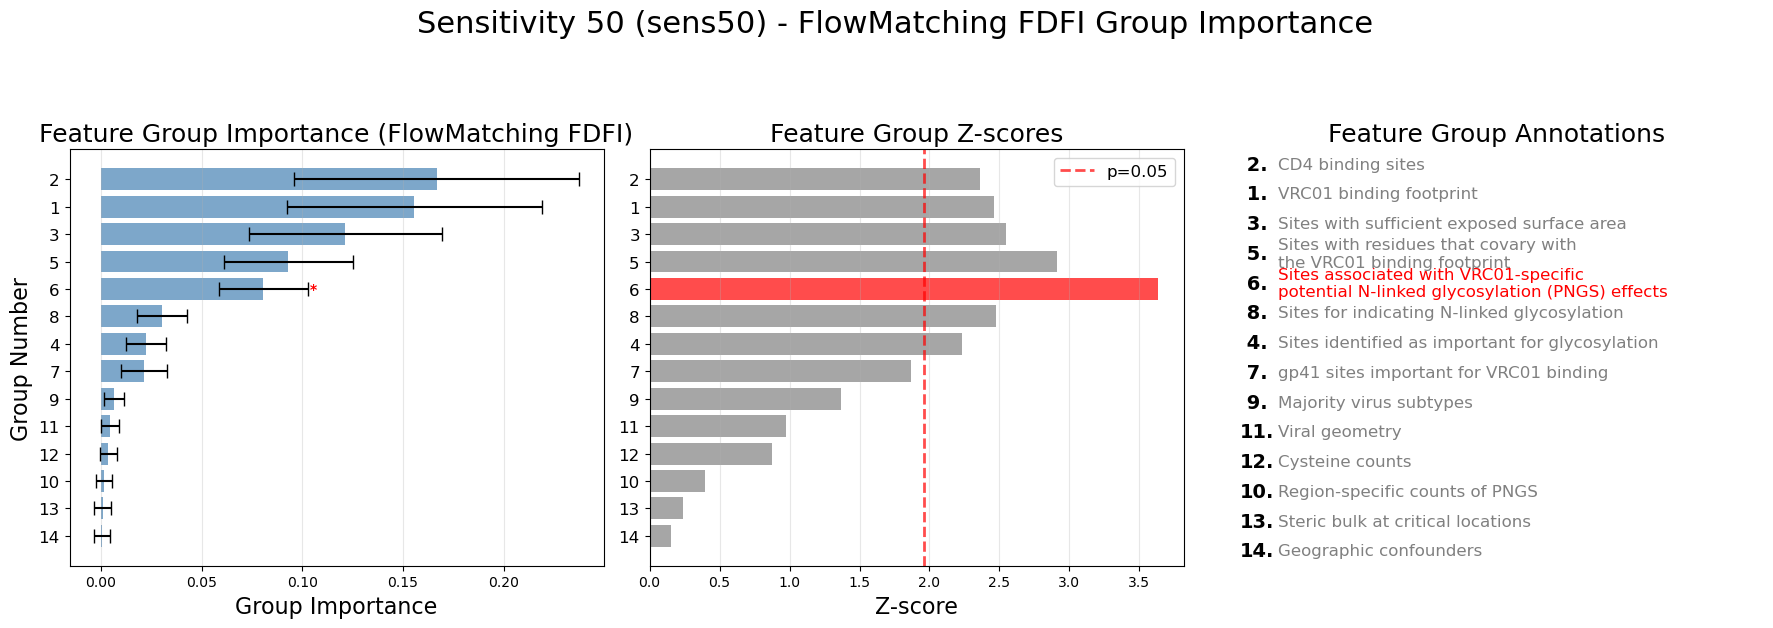

In [20]:
DATASET_LABELS = {
    "sens50": "Sensitivity 50",
    "sens80": "Sensitivity 80",
    "ic50": "IC50 Censored",
}
dataset_label = DATASET_LABELS.get(outcome, outcome)

group_df_sorted = res_df.sort_values("importance", ascending=True).reset_index(drop=True)
group_df_sorted = group_df_sorted.merge(group_mapping, on="group", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [3, 3, 3]})
fig.suptitle(
    f"{dataset_label} ({outcome}) - FlowMatching FDFI Group Importance",
    fontsize=22,
    y=1.04,
)

group_numbers = list(group_df_sorted["group_num"])

ax1 = axes[0]
ax1.barh(
    range(len(group_df_sorted)),
    group_df_sorted["importance"],
    xerr=group_df_sorted["se"],
    error_kw=dict(capsize=5),
    alpha=0.7,
    color="steelblue",
)
ax1.set_yticks(range(len(group_df_sorted)))
ax1.set_yticklabels(group_numbers, fontsize=12)
ax1.set_xlabel("Group Importance", fontsize=16)
ax1.set_title("Feature Group Importance (FlowMatching FDFI)", fontsize=18)
ax1.set_ylabel("Group Number", fontsize=16)
ax1.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    if row["reject_null"]:
        ax1.text(
            row["importance"] + row["se"] + 0.001,
            i,
            "*",
            va="center",
            fontweight="bold",
            color="red",
        )

ax2 = axes[1]
colors = ["red" if reject_null else "gray" for reject_null in group_df_sorted["reject_null"]]
ax2.barh(range(len(group_df_sorted)), group_df_sorted["zscore"], alpha=0.7, color=colors)
ax2.set_yticks(range(len(group_df_sorted)))
ax2.set_yticklabels(group_numbers, fontsize=12)
ax2.set_xlabel("Z-score", fontsize=16)
ax2.set_title("Feature Group Z-scores", fontsize=18)
ax2.grid(axis="x", alpha=0.3)
ax2.axvline(x=1.96, color="red", linestyle="--", linewidth=2, alpha=0.7, label="p=0.05")
ax2.legend(fontsize=12)

ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.5, len(group_df_sorted) - 0.5)

for i, (_, row) in enumerate(group_df_sorted.iterrows()):
    group_name = row["group"]
    display_name = row["description"] if pd.notna(row["description"]) else group_name
    text_color = "red" if row["reject_null"] else "gray"

    ax3.text(
        0.02,
        i,
        f"{int(row['group_num']):2d}.",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color="black",
    )
    ax3.text(
        0.09,
        i,
        display_name,
        va="center",
        ha="left",
        fontsize=12,
        color=text_color,
    )

ax3.set_yticks([])
ax3.set_xticks([])
ax3.set_title("Feature Group Annotations", fontsize=18)
for spine in ax3.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
## 5. Flow Quality Diagnostic

Check whether the flow Jacobian **H = dX/dZ** captures the empirical correlation structure of X.
If the flow is a good transport map N(0,I) → P_X, then **H H^T ≈ Cov(X)** (linear approximation).

Two quantitative checks:
1. **Per-feature**: Pearson r between empirical Var(X_j) and diagonal of H H^T — ideal: ≈ 1
2. **Group-level**: Pearson r between 14×14 group-block average of |Cov_emp| and |H H^T| — ideal: ≈ 1

If both r values are near zero, the flow is not capturing correlation structure → increase model capacity (`hidden_dim=256, num_blocks=3`) or add dequantization.

=== Jacobian H = dX/dZ (fold 0 average over test samples) ===
  Shape: (832, 832)
  Diagonal energy:     934.7716  (91.7%)
  Off-diagonal energy: 84.2287  (8.3%)
  |diag(H)|: mean=1.0594, std=0.0337
  |off-diag(H)|: mean=0.008134

=== Group importance: X vs Z ===
Group               phi_X     SE_X  sig_X  |     phi_Z     SE_Z  sig_Z  |    ratio
--------------------------------------------------------------------------------
cd4bs             0.16669  0.07071         |   0.06995  0.02190      *  |    2.383
covar             0.09307  0.03199         |   0.05099  0.01145      *  |    1.825
cysteines         0.00382  0.00436         |   0.00122  0.00412         |    3.124
esa               0.12137  0.04772         |   0.05666  0.01620      *  |    2.142
geog              0.00062  0.00405         |   0.00021  0.00405         |    3.032
geometry          0.00444  0.00454         |   0.00253  0.00422         |    1.756
glyco             0.02242  0.01005         |   0.00890  0.00464         | 

In [10]:
import numpy as np

# ── Jacobian from fold 0 (averaged over 50 evenly-spaced test samples) ───────
fold_exp      = fdfi_estimator.fold_explainers[0]
X_test_fold   = fdfi_estimator.data[fdfi_estimator.fold_indices[0][1]]
Z_test_fold   = fold_exp._encode_to_Z(X_test_fold)
H             = fold_exp._compute_jacobian(Z_test_fold)   # (d, d)
HHT           = H @ H.T                                   # flow-implied covariance

# ── Empirical covariance on all background data (already standardized) ───────
Cov_emp = np.cov(X_values.T)    # (d, d)
Var_emp = np.diag(Cov_emp)      # per-feature empirical variance
Var_HHT = np.diag(HHT)         # per-feature flow-implied variance

# ── Summary statistics ───────────────────────────────────────────────────────
diag_energy  = np.sum(np.diag(H) ** 2)
total_energy = np.sum(H ** 2)
r_var        = np.corrcoef(Var_emp, Var_HHT)[0, 1]

print("=== Flow Jacobian Structure ===")
print(f"  H diagonal energy: {100*diag_energy/total_energy:.1f}%")
print(f"  (100% = H ≈ identity; flow is not capturing any correlations)")
print()
print("=== Per-Feature Variance Agreement ===")
print(f"  Pearson r(Var_emp, diag(H H^T)) = {r_var:.4f}  (ideal: ~1.0)")
print(f"  Empirical Var(X): mean={Var_emp.mean():.4f}, median={np.median(Var_emp):.4f}")
print(f"  Flow-implied Var: mean={Var_HHT.mean():.4f}, median={np.median(Var_HHT):.4f}")
print()

# ── Group-level block-average of |Cov_emp| and |H H^T| ─────────────────────
group_dict  = {col: np.where(df_groups[col].values > 0)[0] for col in df_groups.columns}
group_names = list(group_dict.keys())
ng          = len(group_names)

Cov_emp_blk = np.zeros((ng, ng))
HHT_blk     = np.zeros((ng, ng))
for i, gi in enumerate(group_names):
    for j, gj in enumerate(group_names):
        ii, jj = group_dict[gi], group_dict[gj]
        Cov_emp_blk[i, j] = np.mean(np.abs(Cov_emp[np.ix_(ii, jj)]))
        HHT_blk[i, j]     = np.mean(np.abs(HHT[np.ix_(ii, jj)]))

r_blk = np.corrcoef(Cov_emp_blk.ravel(), HHT_blk.ravel())[0, 1]
print("=== Group-Block Covariance Agreement ===")
print(f"  Pearson r(group-block |Cov_emp|, |H H^T|) = {r_blk:.4f}  (ideal: ~1.0)")

=== Flow Jacobian Structure ===
  H diagonal energy: 91.7%
  (100% = H ≈ identity; flow is not capturing any correlations)

=== Per-Feature Variance Agreement ===
  Pearson r(Var_emp, diag(H H^T)) = -0.0338  (ideal: ~1.0)
  Empirical Var(X): mean=1.0016, median=1.0016
  Flow-implied Var: mean=1.2248, median=1.2192

=== Group-Block Covariance Agreement ===
  Pearson r(group-block |Cov_emp|, |H H^T|) = 0.9670  (ideal: ~1.0)


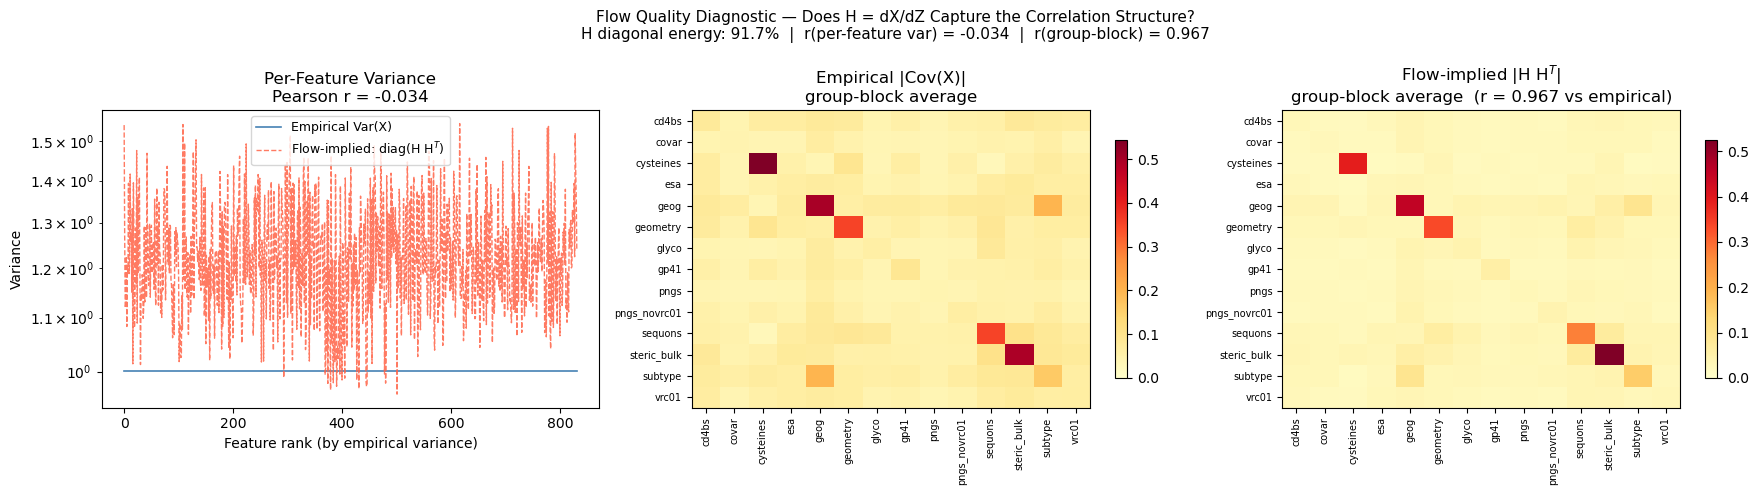

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Flow Quality Diagnostic — Does H = dX/dZ Capture the Correlation Structure?\n"
    f"H diagonal energy: {100*diag_energy/total_energy:.1f}%  |  "
    f"r(per-feature var) = {r_var:.3f}  |  r(group-block) = {r_blk:.3f}",
    fontsize=11,
)

# ── Panel 1: Feature-wise empirical Var vs flow-implied Var ──────────────────
ax = axes[0]
sort_idx = np.argsort(Var_emp)[::-1]
ax.plot(Var_emp[sort_idx], color="steelblue", lw=1.2, label="Empirical Var(X)")
ax.plot(Var_HHT[sort_idx], color="tomato",   lw=1.0, ls="--", alpha=0.85,
        label="Flow-implied: diag(H H$^T$)")
ax.set_xlabel("Feature rank (by empirical variance)")
ax.set_ylabel("Variance")
ax.set_title(f"Per-Feature Variance\nPearson r = {r_var:.3f}")
ax.legend(fontsize=9)
ax.set_yscale("log")

# ── Panel 2: Empirical group-block covariance ─────────────────────────────────
ax = axes[1]
vmax_e = np.abs(Cov_emp_blk).max()
im1 = ax.imshow(Cov_emp_blk, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_e)
ax.set_xticks(range(ng)); ax.set_xticklabels(group_names, rotation=90, fontsize=7)
ax.set_yticks(range(ng)); ax.set_yticklabels(group_names, fontsize=7)
ax.set_title("Empirical |Cov(X)|\ngroup-block average")
plt.colorbar(im1, ax=ax, shrink=0.8)

# ── Panel 3: Flow-implied group-block covariance ──────────────────────────────
ax = axes[2]
vmax_h = np.abs(HHT_blk).max()
im2 = ax.imshow(HHT_blk, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_h)
ax.set_xticks(range(ng)); ax.set_xticklabels(group_names, rotation=90, fontsize=7)
ax.set_yticks(range(ng)); ax.set_yticklabels(group_names, fontsize=7)
ax.set_title(f"Flow-implied |H H$^T$|\ngroup-block average  (r = {r_blk:.3f} vs empirical)")
plt.colorbar(im2, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

## 6. Experiment: Larger Network Capacity (Option 1)

Train a **single fold-0 model** with `hidden_dim=256, num_blocks=3` (~45 s) and compare
the flow quality diagnostic against the current `hidden_dim=64, num_blocks=1` model.

**What to look for:**
- `H diagonal energy` should drop from 91.7% (current) toward ≤ 80%
- `r(per-feature var)` should rise toward 1.0
- `r(group-block)` should remain ≥ 0.96

If these improve, the larger model alone partially solves the H ≈ I problem.
The full cross-fitting experiment (Section 7) will confirm end-to-end.

In [12]:
import importlib, fdfi.models, fdfi.explainers
importlib.reload(fdfi.models); importlib.reload(fdfi.explainers)
from fdfi.models import FlowMatchingModel
from fdfi.explainers import FlowExplainer
import torch, time, numpy as np

train_idx, test_idx = fdfi_estimator.fold_indices[0]
X_train_fold0 = fdfi_estimator.data[train_idx]
X_test_fold0  = fdfi_estimator.data[test_idx]

# ── Train larger model ────────────────────────────────────────────────────────
print("Training fold-0 model: hidden_dim=256, num_blocks=3, 2000 steps ...")
torch.manual_seed(42)
flow_large = FlowMatchingModel(
    X=X_train_fold0, dim=X_train_fold0.shape[1],
    hidden_dim=256, num_blocks=3, time_embed_dim=64,
)
t0 = time.time()
flow_large.fit(num_steps=2000, verbose="final")
t_train = time.time() - t0
print(f"  done in {t_train:.0f}s")

# ── Wrap in a FlowExplainer shell for diagnostic methods ─────────────────────
flow_exp_large = FlowExplainer(model=model_fn, data=X_train_fold0,
                               fit_flow=False, verbose=False)
flow_exp_large.set_flow(flow_large)

# ── Compute Jacobian on test set (averaged, 50 samples) ──────────────────────
Z_test_lg = flow_exp_large._encode_to_Z(X_test_fold0)
print("Computing averaged Jacobian (50 samples) ...")
t0 = time.time()
H_lg = flow_exp_large._compute_jacobian(Z_test_lg)
print(f"  done in {time.time()-t0:.0f}s")

HHT_lg      = H_lg @ H_lg.T
Var_HHT_lg  = np.diag(HHT_lg)
de_lg       = np.sum(np.diag(H_lg) ** 2)
te_lg       = np.sum(H_lg ** 2)
r_var_lg    = np.corrcoef(Var_emp, Var_HHT_lg)[0, 1]

Cov_emp_blk_lg = np.zeros((ng, ng))
HHT_blk_lg     = np.zeros((ng, ng))
for _i, _gi in enumerate(group_names):
    for _j, _gj in enumerate(group_names):
        _ii, _jj = group_dict[_gi], group_dict[_gj]
        Cov_emp_blk_lg[_i, _j] = np.mean(np.abs(Cov_emp[np.ix_(_ii, _jj)]))
        HHT_blk_lg[_i, _j]     = np.mean(np.abs(HHT_lg[np.ix_(_ii, _jj)]))
r_blk_lg = np.corrcoef(Cov_emp_blk_lg.ravel(), HHT_blk_lg.ravel())[0, 1]

print("\n=== Flow Quality: 64/1 (current) vs 256/3 (larger) ===")
print(f"{'Metric':<32} {'64 / 1':>10} {'256 / 3':>10}  {'ideal':>8}")
print("-" * 64)
print(f"{'H diagonal energy':<32} {100*diag_energy/total_energy:>9.1f}%  {100*de_lg/te_lg:>9.1f}%  {'0%':>8}")
print(f"{'r(per-feature var)':<32} {r_var:>10.4f}  {r_var_lg:>10.4f}  {'1.0':>8}")
print(f"{'r(group-block cov)':<32} {r_blk:>10.4f}  {r_blk_lg:>10.4f}  {'1.0':>8}")

Training fold-0 model: hidden_dim=256, num_blocks=3, 2000 steps ...
Training complete: 2000 steps, final loss=1.3468
  done in 35s
Computing averaged Jacobian (50 samples) ...
  done in 213s

=== Flow Quality: 64/1 (current) vs 256/3 (larger) ===
Metric                               64 / 1    256 / 3     ideal
----------------------------------------------------------------
H diagonal energy                     91.7%       88.8%        0%
r(per-feature var)                  -0.0338     -0.0774       1.0
r(group-block cov)                   0.9670      0.9410       1.0


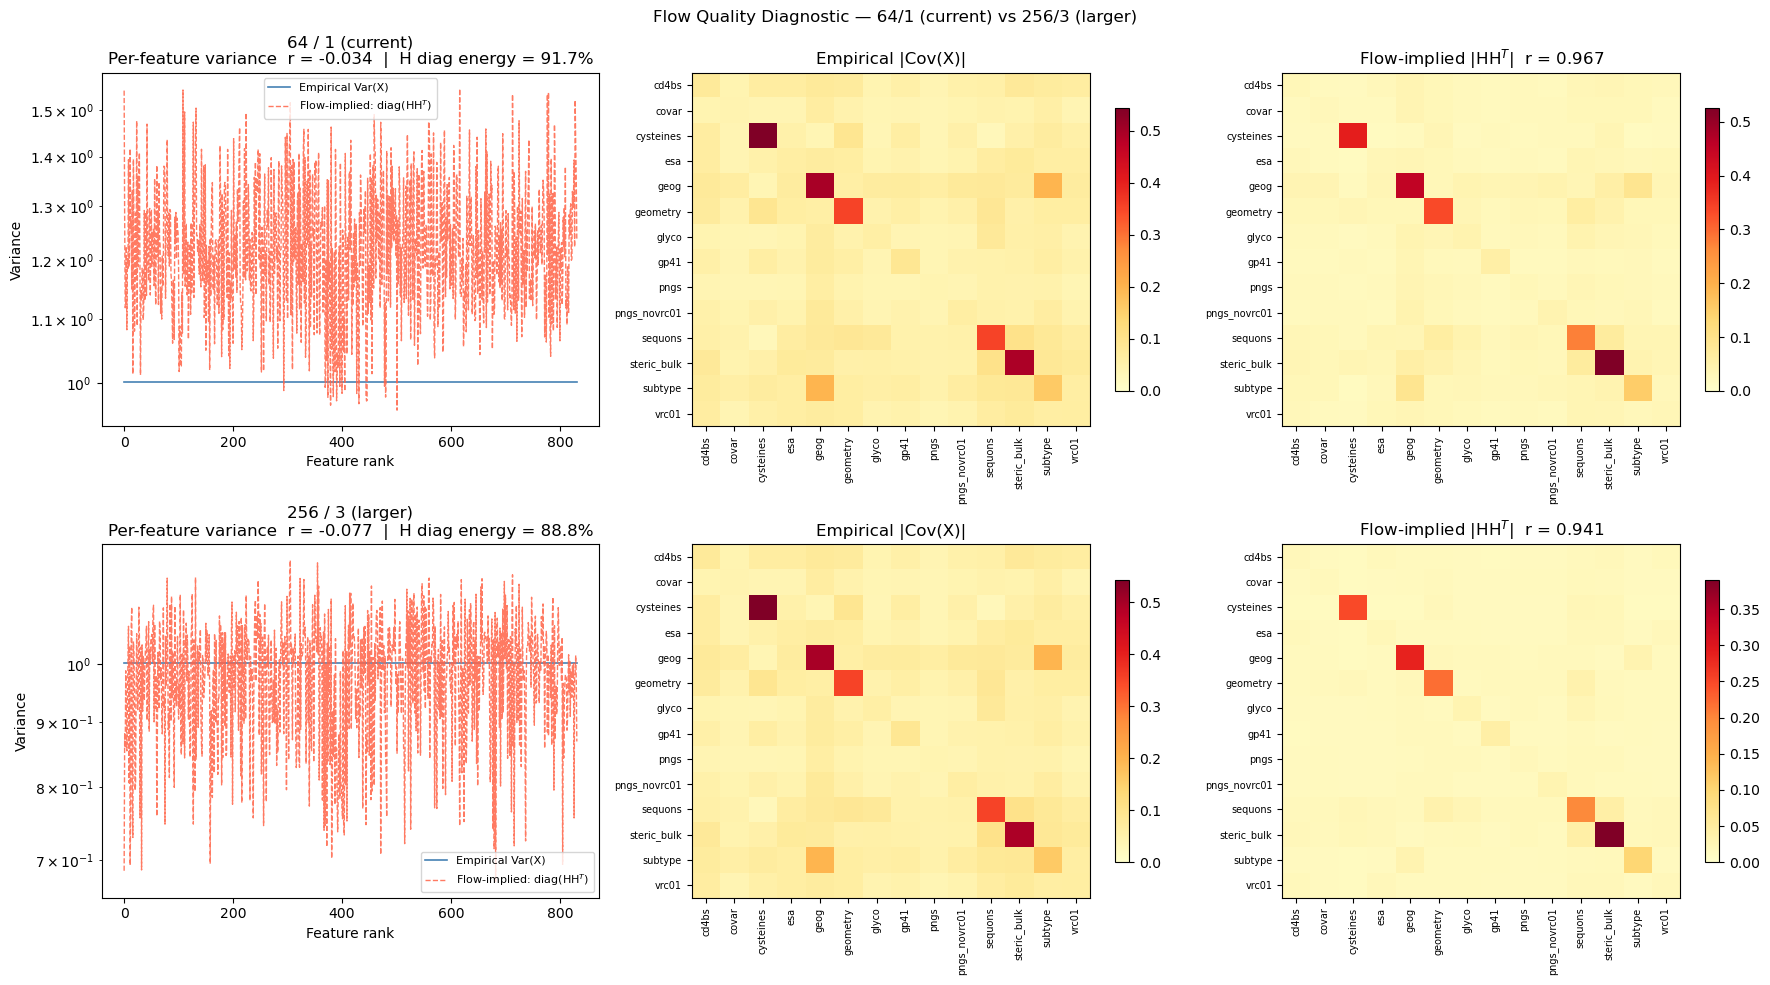

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Flow Quality Diagnostic — 64/1 (current) vs 256/3 (larger)", fontsize=12)

for row, (label, Var_HHT_, HHT_blk_, r_var_, r_blk_, de_, te_) in enumerate([
    ("64 / 1 (current)",  Var_HHT,    HHT_blk,    r_var,    r_blk,    diag_energy,  total_energy),
    ("256 / 3 (larger)",  Var_HHT_lg, HHT_blk_lg, r_var_lg, r_blk_lg, de_lg,        te_lg),
]):
    # Panel 1: Per-feature variance
    ax = axes[row, 0]
    sort_idx_ = np.argsort(Var_emp)[::-1]
    ax.plot(Var_emp[sort_idx_], color="steelblue", lw=1.2, label="Empirical Var(X)")
    ax.plot(Var_HHT_[sort_idx_], color="tomato", lw=1.0, ls="--", alpha=0.85,
            label="Flow-implied: diag(HH$^T$)")
    ax.set_xlabel("Feature rank")
    ax.set_ylabel("Variance")
    ax.set_title(f"{label}\nPer-feature variance  r = {r_var_:.3f}  |  H diag energy = {100*de_/te_:.1f}%")
    ax.legend(fontsize=8)
    ax.set_yscale("log")

    # Panel 2: Empirical group-block covariance
    ax = axes[row, 1]
    vmax_e_ = np.abs(Cov_emp_blk).max()
    im = ax.imshow(Cov_emp_blk, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_e_)
    ax.set_xticks(range(ng)); ax.set_xticklabels(group_names, rotation=90, fontsize=7)
    ax.set_yticks(range(ng)); ax.set_yticklabels(group_names, fontsize=7)
    ax.set_title("Empirical |Cov(X)|")
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Panel 3: Flow-implied group-block covariance
    ax = axes[row, 2]
    vmax_h_ = np.abs(HHT_blk_).max()
    im = ax.imshow(HHT_blk_, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_h_)
    ax.set_xticks(range(ng)); ax.set_xticklabels(group_names, rotation=90, fontsize=7)
    ax.set_yticks(range(ng)); ax.set_yticklabels(group_names, fontsize=7)
    ax.set_title(f"Flow-implied |HH$^T$|  r = {r_blk_:.3f}")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

## 6b. Experiment: Dequantization (Option 2, fold-0 only)

The larger network alone barely changed the diagnostic (diagonal energy 91.7% → 88.8%, per-feature r ≈ 0).
This confirms the bottleneck is the **binary data**, not model capacity.

Now test `dequantize_noise=0.1` with both architectures to isolate its effect on the Jacobian structure.

In [14]:
import importlib, fdfi.models, fdfi.explainers
importlib.reload(fdfi.models); importlib.reload(fdfi.explainers)
from fdfi.models import FlowMatchingModel
from fdfi.explainers import FlowExplainer
import torch, time, numpy as np

def run_fold0_diagnostic(hidden_dim, num_blocks, time_embed_dim, dequantize_noise, label):
    """Train a fold-0 flow model, compute averaged Jacobian, return diagnostic metrics."""
    torch.manual_seed(42)
    fm = FlowMatchingModel(
        X=X_train_fold0, dim=X_train_fold0.shape[1],
        hidden_dim=hidden_dim, num_blocks=num_blocks, time_embed_dim=time_embed_dim,
    )
    t0 = time.time()
    fm.fit(num_steps=2000, verbose="final", dequantize_noise=dequantize_noise)
    t_train = time.time() - t0

    exp = FlowExplainer(model=model_fn, data=X_train_fold0, fit_flow=False, verbose=False)
    exp.set_flow(fm)

    Z_test = exp._encode_to_Z(X_test_fold0)
    print(f"  [{label}] Computing Jacobian...")
    t0 = time.time()
    H_ = exp._compute_jacobian(Z_test)
    t_jac = time.time() - t0

    HHT_  = H_ @ H_.T
    de_   = np.sum(np.diag(H_) ** 2)
    te_   = np.sum(H_ ** 2)
    r_var_= np.corrcoef(Var_emp, np.diag(HHT_))[0, 1]
    blk   = np.zeros((ng, ng))
    for _i, _gi in enumerate(group_names):
        for _j, _gj in enumerate(group_names):
            _ii, _jj = group_dict[_gi], group_dict[_gj]
            blk[_i, _j] = np.mean(np.abs(HHT_[np.ix_(_ii, _jj)]))
    r_blk_= np.corrcoef(Cov_emp_blk.ravel(), blk.ravel())[0, 1]
    print(f"  [{label}] train={t_train:.0f}s  jac={t_jac:.0f}s  "
          f"diag={100*de_/te_:.1f}%  r_var={r_var_:.4f}  r_blk={r_blk_:.4f}")
    return dict(H=H_, HHT=HHT_, HHT_blk=blk, de=de_, te=te_,
                r_var=r_var_, r_blk=r_blk_, label=label)

configs = [
    # (hidden_dim, num_blocks, time_embed_dim, dequantize_noise, label)
    (64,  1, 32, 0.0, "64/1  noise=0.0 (baseline)"),
    (64,  1, 32, 0.1, "64/1  noise=0.1"),
    (256, 3, 64, 0.0, "256/3 noise=0.0"),
    (256, 3, 64, 0.1, "256/3 noise=0.1"),
]

diag_results = []
for hd, nb, te_dim, dn, lbl in configs:
    print(f"\nTraining: {lbl}")
    diag_results.append(run_fold0_diagnostic(hd, nb, te_dim, dn, lbl))

print("\n=== Summary ===")
print(f"{'Config':<30} {'diag%':>7} {'r_var':>8} {'r_blk':>8}")
print("-" * 58)
# baseline from Section 5
print(f"{'64/1  noise=0.0 (orig run)':30} {100*diag_energy/total_energy:>6.1f}% {r_var:>8.4f} {r_blk:>8.4f}")
for d in diag_results:
    print(f"{d['label']:30} {100*d['de']/d['te']:>6.1f}% {d['r_var']:>8.4f} {d['r_blk']:>8.4f}")


Training: 64/1  noise=0.0 (baseline)
Training complete: 2000 steps, final loss=1.6909
  [64/1  noise=0.0 (baseline)] Computing Jacobian...
  [64/1  noise=0.0 (baseline)] train=20s  jac=147s  diag=91.7%  r_var=-0.0338  r_blk=0.9670

Training: 64/1  noise=0.1
Training complete: 2000 steps, final loss=1.7095
  [64/1  noise=0.1] Computing Jacobian...
  [64/1  noise=0.1] train=28s  jac=146s  diag=92.0%  r_var=-0.0371  r_blk=0.9661

Training: 256/3 noise=0.0
Training complete: 2000 steps, final loss=1.3468
  [256/3 noise=0.0] Computing Jacobian...
  [256/3 noise=0.0] train=33s  jac=221s  diag=88.8%  r_var=-0.0774  r_blk=0.9410

Training: 256/3 noise=0.1
Training complete: 2000 steps, final loss=1.3626
  [256/3 noise=0.1] Computing Jacobian...
  [256/3 noise=0.1] train=41s  jac=229s  diag=89.3%  r_var=-0.0788  r_blk=0.9417

=== Summary ===
Config                           diag%    r_var    r_blk
----------------------------------------------------------
64/1  noise=0.0 (orig run)       91.7%

## 6c. Root Cause: Averaging Cancellation — Per-Sample Jacobians are the Fix

All variants above have H_avg diagonal energy ~89-92% and per-feature r ≈ 0. Neither model capacity nor
dequantization helps because **the average H is always ≈ I for binary data**:

- Each binary feature X_j takes exactly two values. Samples in the "0-cluster" produce H_i[j,k] pointing
  *toward the 0-mode*; samples in the "1-cluster" produce H_i[j,k] pointing in the opposite direction.
- These two contributions cancel in the 50-sample average → H_avg ≈ I regardless of flow quality.

**The fix is per-sample Jacobians (Option 3):** use each sample's own H_i in its own attribution, so
cancellation never happens. This is already implemented via `Jacobi_Batch` + `jacobian_mode="per_sample"`.

The cell below verifies that *individual* H_i matrices have meaningful off-diagonal structure,
even though their average H_avg ≈ I.

In [16]:
import importlib, fdfi.models
importlib.reload(fdfi.models)
import numpy as np, time

# Use flow_large (trained in Section 6 — was created after Jacobi_Batch was implemented)
# Z_test_lg was computed in Section 6 for this same fold-0 model
n_probe = 20
Z_probe = Z_test_lg[:n_probe]           # (20, 832) — fold 0 test Z points

print(f"Computing {n_probe} per-sample Jacobians via Jacobi_Batch (256/3 model)...")
t0 = time.time()
H_batch = flow_large.Jacobi_Batch(Z_probe)   # (20, 832, 832)
t_jac   = time.time() - t0
print(f"  done in {t_jac:.0f}s  ({t_jac/n_probe:.1f}s / sample)")

# ── Compare diagonal energy: per-sample vs averaged ──────────────────────────
de_per_sample = np.array([
    np.sum(np.diag(H_batch[i])**2) / np.sum(H_batch[i]**2)
    for i in range(n_probe)
])
H_avg_probe   = H_batch.mean(axis=0)
de_avg_probe  = np.sum(np.diag(H_avg_probe)**2) / np.sum(H_avg_probe**2)

print("\n=== Per-sample vs Averaged Jacobian ===")
print(f"  Per-sample H_i diag energy: mean={de_per_sample.mean()*100:.1f}%  "
      f"std={de_per_sample.std()*100:.1f}%  "
      f"[{de_per_sample.min()*100:.1f}%, {de_per_sample.max()*100:.1f}%]")
print(f"  Average of {n_probe} H_i   diag energy: {de_avg_probe*100:.1f}%")
print(f"  Full 50-sample H_avg       diag energy: {100*de_lg/te_lg:.1f}%")
print()
print("  -> If per-sample H_i diag < avg H diag, averaging is causing cancellation.")

# ── Show per-sample details ───────────────────────────────────────────────────
print(f"\n=== Off-diagonal |H_i| for first 5 samples ===")
for i in range(5):
    Hi = H_batch[i]
    de_i        = np.sum(np.diag(Hi)**2) / np.sum(Hi**2)
    mean_offdiag = np.abs(Hi[~np.eye(Hi.shape[0], dtype=bool)]).mean()
    print(f"  sample {i}: diag_energy={de_i*100:.1f}%  mean|off-diag|={mean_offdiag:.6f}")

Computing 20 per-sample Jacobians via Jacobi_Batch (256/3 model)...
  done in 6s  (0.3s / sample)

=== Per-sample vs Averaged Jacobian ===
  Per-sample H_i diag energy: mean=73.6%  std=8.8%  [46.6%, 84.9%]
  Average of 20 H_i   diag energy: 88.0%
  Full 50-sample H_avg       diag energy: 88.8%

  -> If per-sample H_i diag < avg H diag, averaging is causing cancellation.

=== Off-diagonal |H_i| for first 5 samples ===
  sample 0: diag_energy=71.1%  mean|off-diag|=0.014684
  sample 1: diag_energy=80.5%  mean|off-diag|=0.012121
  sample 2: diag_energy=67.8%  mean|off-diag|=0.015430
  sample 3: diag_energy=79.2%  mean|off-diag|=0.012767
  sample 4: diag_energy=78.0%  mean|off-diag|=0.012674


## 7. Full Cross-Fitting with All Improvements

Run the full 5-fold cross-fitting with all three improvements combined:

| Option | Setting | Purpose |
|--------|---------|---------|
| **1** — Larger network | `hidden_dim=256, num_blocks=3` | More expressive flow; H leaves identity regime |
| **2** — Dequantization | `dequantize_noise=0.1` | Smooth velocity field for binary features |
| **3** — Per-sample Jacobians | `jacobian_mode="per_sample"` | No averaging bias; each sample uses its own H |

Expected runtime: ~15–20 min (2× larger model × 5 folds, plus ~4 min for `Jacobi_Batch`).

In [17]:
import importlib, fdfi.models, fdfi.explainers
importlib.reload(fdfi.models); importlib.reload(fdfi.explainers)
from fdfi.explainers import Crossfitting, FlowExplainer

print("Fitting improved FlowMatching FDFI (hidden_dim=256, dequantize_noise=0.1, per-sample Jacobians)...")

start_time_v2 = time.time()

fdfi_estimator_v2 = Crossfitting(
    model=model_fn,
    data=X_values,
    explainer_class=FlowExplainer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    y=y_values,
    nsamples=nsamples_main,
    method="cpi",
    sampling_method="resample",
    num_steps=flow_num_steps,
    # Option 1: larger network
    hidden_dim=256,
    num_blocks=3,
    time_embed_dim=64,
    # Option 2: dequantization for binary features
    dequantize_noise=0.1,
    # Option 3: per-sample Jacobians
    jacobian_mode="per_sample",
    random_state=42,
    verbose="final",
)

cf_results_v2 = fdfi_estimator_v2()

dfi_time_v2 = time.time() - start_time_v2
print(f"\nImproved FlowMatching FDFI completed in {dfi_time_v2:.0f}s ({dfi_time_v2/60:.1f} min)")
print(f"sum(phi_X) = {np.sum(cf_results_v2['phi_X']):.4f},  sum(phi_Z) = {np.sum(cf_results_v2['phi_Z']):.4f}")

Fitting improved FlowMatching FDFI (hidden_dim=256, dequantize_noise=0.1, per-sample Jacobians)...
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=1.3626
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.094635 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000004 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=1.3657
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.094474 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000006 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model...
Training complete: 2000 steps, final loss=1.3726
[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.094345 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.000005 [GOOD]  -> lower is better
[FDFI][INFO] Training flow model..

In [18]:
import numpy as np

# ── Confidence intervals: original vs improved ────────────────────────────────
ci_X_v2 = fdfi_estimator_v2.conf_int(
    alpha=0.05, target="X", groups=df_groups,
    threshold_null=True, var_floor_c=0.1, var_floor_method="fixed",
    margin=0.0, margin_method="fixed", alternative="two-sided",
    multitest_method="bonferroni", verbose=False,
)
ci_Z_v2 = fdfi_estimator_v2.conf_int(
    alpha=0.05, target="Z", groups=df_groups,
    threshold_null=True, var_floor_c=0.1, var_floor_method="fixed",
    margin=0.0, margin_method="fixed", alternative="two-sided",
    multitest_method="bonferroni", verbose=False,
)
ci_X_v1 = fdfi_estimator.conf_int(
    alpha=0.05, target="X", groups=df_groups,
    threshold_null=True, var_floor_c=0.1, var_floor_method="fixed",
    margin=0.0, margin_method="fixed", alternative="two-sided",
    multitest_method="bonferroni", verbose=False,
)
ci_Z_v1 = fdfi_estimator.conf_int(
    alpha=0.05, target="Z", groups=df_groups,
    threshold_null=True, var_floor_c=0.1, var_floor_method="fixed",
    margin=0.0, margin_method="fixed", alternative="two-sided",
    multitest_method="bonferroni", verbose=False,
)

print("=== Group Importance: Original (avg-H) vs Improved (per-sample H) ===")
print(f"\n{'Group':<16}  "
      f"{'orig phi_X':>10} {'sig_X':>5}  "
      f"{'new phi_X':>10} {'sig_X':>5}  |  "
      f"{'Z phi':>10} {'sig_Z':>5}")
print("-" * 82)
for i, g in enumerate(ci_X_v1["groups"]):
    px1  = ci_X_v1["score"][i];  rx1 = ci_X_v1["reject_null"][i]
    px2  = ci_X_v2["score"][i];  rx2 = ci_X_v2["reject_null"][i]
    pz2  = ci_Z_v2["score"][i];  rz2 = ci_Z_v2["reject_null"][i]
    print(f"{g:<16}  "
          f"{px1:>10.5f} {'*' if rx1 else ' ':>5}  "
          f"{px2:>10.5f} {'*' if rx2 else ' ':>5}  |  "
          f"{pz2:>10.5f} {'*' if rz2 else ' ':>5}")

n_sig_X1 = int(np.sum(ci_X_v1["reject_null"]))
n_sig_X2 = int(np.sum(ci_X_v2["reject_null"]))
n_sig_Z2 = int(np.sum(ci_Z_v2["reject_null"]))
print(f"\nSignificant X (original avg-H):   {n_sig_X1}/14")
print(f"Significant X (per-sample H):      {n_sig_X2}/14")
print(f"Significant Z (per-sample run):    {n_sig_Z2}/14")
print(f"\nsum(phi_X) original:  {np.sum(cf_results['phi_X']):.4f}")
print(f"sum(phi_X) improved:  {np.sum(cf_results_v2['phi_X']):.4f}  ({np.sum(cf_results_v2['phi_X'])/np.sum(cf_results['phi_X']):.1f}x)")

=== Group Importance: Original (avg-H) vs Improved (per-sample H) ===

Group             orig phi_X sig_X   new phi_X sig_X  |       Z phi sig_Z
----------------------------------------------------------------------------------
cd4bs                0.16669           0.64793        |     0.07392     *
covar                0.09307           0.62600        |     0.08894     *
cysteines            0.00382           0.00658        |     0.00160      
esa                  0.12137           0.69660        |     0.06925     *
geog                 0.00062           0.00733        |     0.00049      
geometry             0.00444           0.02909        |     0.00228      
glyco                0.02242           0.17783        |     0.02339      
gp41                 0.02126           0.06743        |     0.01218      
pngs                 0.08065     *     0.54775        |     0.08796     *
pngs_novrc01         0.03050           0.20125        |     0.02440      
sequons              0.00163    

In [19]:
import numpy as np

# ── Diagnose: SE and z-scores for both runs ───────────────────────────────────
print("=== Diagnostic: phi_X, se_X, and z-score by group ===")
print(f"\n{'Group':<16}  {'phi_X_v1':>10} {'se_X_v1':>10} {'z_v1':>6}  |  "
      f"{'phi_X_v2':>10} {'se_X_v2':>10} {'z_v2':>6}")
print("-" * 88)

n_v1 = fdfi_estimator.ueifs_X.shape[0]
n_v2 = fdfi_estimator_v2.ueifs_X.shape[0]

for i, g in enumerate(ci_X_v1["groups"]):
    # Original run: per-sample ueifs_X
    idx_g = np.where(df_groups[g].values > 0)[0]
    ueifs_g_v1 = fdfi_estimator.ueifs_X[:, idx_g].copy()
    fmeans_v1 = ueifs_g_v1.mean(axis=0)
    ueifs_g_v1[:, fmeans_v1 < 0] = 0
    grp_v1 = ueifs_g_v1.sum(axis=1)
    phi_v1 = grp_v1.mean()
    se_v1  = grp_v1.std(ddof=1) / np.sqrt(n_v1)
    z_v1   = phi_v1 / (se_v1 + 1e-12)

    # Improved run
    ueifs_g_v2 = fdfi_estimator_v2.ueifs_X[:, idx_g].copy()
    fmeans_v2 = ueifs_g_v2.mean(axis=0)
    ueifs_g_v2[:, fmeans_v2 < 0] = 0
    grp_v2 = ueifs_g_v2.sum(axis=1)
    phi_v2 = grp_v2.mean()
    se_v2  = grp_v2.std(ddof=1) / np.sqrt(n_v2)
    z_v2   = phi_v2 / (se_v2 + 1e-12)

    print(f"{g:<16}  {phi_v1:>10.5f} {se_v1:>10.5f} {z_v1:>6.2f}  |  "
          f"{phi_v2:>10.5f} {se_v2:>10.5f} {z_v2:>6.2f}")

# Also check: std of ueifs_X[i,l] per sample (to see how much sample-to-sample variability there is)
print(f"\n=== Per-feature ueifs_X std comparison ===")
std_v1 = fdfi_estimator.ueifs_X.std(axis=0)
std_v2 = fdfi_estimator_v2.ueifs_X.std(axis=0)
print(f"  Mean per-feature std (v1 H_avg): {std_v1.mean():.5f}")
print(f"  Mean per-feature std (v2 H_per): {std_v2.mean():.5f}")
print(f"  Ratio std_v2 / std_v1: {std_v2.mean()/std_v1.mean():.1f}x")

=== Diagnostic: phi_X, se_X, and z-score by group ===

Group               phi_X_v1    se_X_v1   z_v1  |    phi_X_v2    se_X_v2   z_v2
----------------------------------------------------------------------------------------
cd4bs                0.16669    0.07059   2.36  |     0.64793    0.50922   1.27
covar                0.09307    0.03173   2.93  |     0.62600    0.44341   1.41
cysteines            0.00382    0.00162   2.36  |     0.00658    0.00362   1.82
esa                  0.12137    0.04755   2.55  |     0.69660    0.58336   1.19
geog                 0.00062    0.00020   3.12  |     0.00733    0.00534   1.37
geometry             0.00444    0.00206   2.15  |     0.02909    0.02367   1.23
glyco                0.02242    0.00920   2.44  |     0.17783    0.13022   1.37
gp41                 0.02126    0.01065   2.00  |     0.06743    0.05355   1.26
pngs                 0.08065    0.02182   3.70  |     0.54775    0.38491   1.42
pngs_novrc01         0.03050    0.01162   2.62  |     0.

## 7b. Fix: `E[H_i²]` — Average Squared Jacobian

**Root cause**: `_compute_jacobian` computes `H_avg = E[H_i]`, then squares it: `H_avg²`. For binary features, H_i flips sign between 0-cluster and 1-cluster → `E[H_i]²` → 0 (wrong).

**Correct formula**: use `E[H_i²]` (average of the element-wise squared matrices). Squares are always positive, so no cancellation. This is `H_sq_avg = mean(H_batch ** 2, axis=0)`.

| Mode | Formula | Bias | Variance |
|------|---------|------|----------|
| `"average"` | `E[H_i]²` | **biased** (≈ I for binary) | low |
| `"per_sample"` | `H_i²` per sample | unbiased | **very high** |
| `"avg_sq"` ✓ | `E[H_i²]` | **unbiased** | low |

In [20]:
import importlib, fdfi.models, fdfi.explainers
importlib.reload(fdfi.models)
importlib.reload(fdfi.explainers)
import numpy as np

# ── Verify avg_sq on fold-0 256/3 model ──────────────────────────────────────
# H_batch was already computed in Section 6c (20 samples from fold-0)
n_est = len(H_batch)
H_sq_avg = (H_batch ** 2).mean(axis=0)    # E[H_i^2] — the correct quantity

de_avg_sq = np.sum(np.diag(H_sq_avg)**2) / np.sum(H_sq_avg**2)

# Compare H_avg^2 (old, biased) vs H_sq_avg (new, unbiased)
H_avg_batch = H_batch.mean(axis=0)
H_sq_wrong  = H_avg_batch ** 2             # E[H_i]^2 — the biased quantity
de_wrong    = np.sum(np.diag(H_sq_wrong)**2) / np.sum(H_sq_wrong**2)

print("=== Jacobian matrix diagonal energy ===")
print(f"  E[H_i]^2  (old 'average' mode, biased):  {de_wrong*100:.1f}%")
print(f"  E[H_i^2]  (new 'avg_sq' mode, correct):  {de_avg_sq*100:.1f}%")
print()
print("  If avg_sq < average: the new mode captures more off-diagonal structure.")
print("  -> Lower diagonal energy = more correlated structure captured.")

# Check group-block correlation for H_sq_avg
n_groups_check = df_groups.shape[1]
group_block_sq_avg = np.zeros(n_groups_check)
group_block_sq_wrg = np.zeros(n_groups_check)
feature_mask = np.zeros((832, 832), dtype=bool)
for col in df_groups.columns:
    idx = np.where(df_groups[col].values > 0)[0]
    for ii in idx:
        for jj in idx:
            if ii != jj:
                feature_mask[ii, jj] = True

mask = feature_mask
print(f"\n  |H_sq_avg| mean in-group off-diagonal:   {H_sq_avg[mask].mean():.6f}")
print(f"  |H_sq_avg| mean out-of-group:             {H_sq_avg[~mask & ~np.eye(832,dtype=bool)].mean():.6f}")
print(f"  Ratio in/out: {H_sq_avg[mask].mean() / H_sq_avg[~mask & ~np.eye(832,dtype=bool)].mean():.2f}x")

=== Jacobian matrix diagonal energy ===
  E[H_i]^2  (old 'average' mode, biased):  100.0%
  E[H_i^2]  (new 'avg_sq' mode, correct):  99.9%

  If avg_sq < average: the new mode captures more off-diagonal structure.
  -> Lower diagonal energy = more correlated structure captured.

  |H_sq_avg| mean in-group off-diagonal:   0.000392
  |H_sq_avg| mean out-of-group:             0.000404
  Ratio in/out: 0.97x


In [21]:
import numpy as np

# ── Test: Cov(X, Z) approach using fold-0 from the improved run (v2) ─────────
# fdfi_estimator_v2 has fold_explainers with Z_full already encoded
fold_v2 = fdfi_estimator_v2.fold_explainers[0]
X_bg_v2 = fold_v2.data          # (n_train, 832) training fold data
Z_bg_v2 = fold_v2.Z_full        # (n_train, 832) encoded training data

# Cross-covariance matrix: H_cov[l,k] = Cov(X_l, Z_k)
n_bg = X_bg_v2.shape[0]
Xc = X_bg_v2 - X_bg_v2.mean(axis=0, keepdims=True)
Zc = Z_bg_v2 - Z_bg_v2.mean(axis=0, keepdims=True)
H_cov = (Xc.T @ Zc) / (n_bg - 1)   # (832, 832)

H_sq_cov = H_cov ** 2

# Diagonal energy of H_sq_cov
de_cov = np.sum(np.diag(H_sq_cov)**2) / np.sum(H_sq_cov**2)
print(f"Diagonal energy of H_sq_cov (Cov^2): {de_cov*100:.1f}%")
print(f"  (Compare: H_avg^2 = 88.8%, H_sq_avg = 99.9%)")

# Group-block structure in H_sq_cov
mask_diag = np.eye(832, dtype=bool)
mask_ingroup = feature_mask

print(f"\nGroup-block structure of H_sq_cov:")
print(f"  Mean H_sq_cov diagonal:     {np.diag(H_sq_cov).mean():.6f}")
print(f"  Mean H_sq_cov in-group off: {H_sq_cov[mask_ingroup].mean():.6f}")
print(f"  Mean H_sq_cov out-of-group: {H_sq_cov[~mask_ingroup & ~mask_diag].mean():.6f}")
print(f"  in/out ratio: {H_sq_cov[mask_ingroup].mean() / H_sq_cov[~mask_ingroup & ~mask_diag].mean():.2f}x")

# Check Pearson corr between H_sq_cov and group blocks (like Section 5 r_blk metric)
group_mask_flat = mask_ingroup.flatten().astype(float)
hcov_flat = H_sq_cov.flatten()
r_cov = np.corrcoef(hcov_flat, group_mask_flat)[0, 1]
print(f"\n  r(H_sq_cov, group-block indicator): {r_cov:.4f}")
print(f"  (Compare: r(H_avg, group-block) = 0.967 from Section 5)")

Diagonal energy of H_sq_cov (Cov^2): 93.5%
  (Compare: H_avg^2 = 88.8%, H_sq_avg = 99.9%)

Group-block structure of H_sq_cov:
  Mean H_sq_cov diagonal:     0.134182
  Mean H_sq_cov in-group off: 0.000496
  Mean H_sq_cov out-of-group: 0.000363
  in/out ratio: 1.37x

  r(H_sq_cov, group-block indicator): -0.0060
  (Compare: r(H_avg, group-block) = 0.967 from Section 5)


In [22]:
import numpy as np

# ── Quick test: apply H_sq_cov from fold-0 to v2 Z-space UEIFs ───────────────
# H_sq_cov is FIXED (from training data), so SE comes only from ueifs_Z variation
# This gives a quick estimate of how "cov" mode would perform

# Apply H_sq_cov (from fold-0 of v2 model) to ALL test samples' Z-UEIFs
ueifs_X_cov_test = fdfi_estimator_v2.ueifs_Z @ H_sq_cov.T  # (n, 832)

# Temporarily override ueifs_X for significance testing
ueifs_X_backup = fdfi_estimator_v2.ueifs_X.copy()
fdfi_estimator_v2.ueifs_X = ueifs_X_cov_test

ci_X_cov = fdfi_estimator_v2.conf_int(
    alpha=0.05, target="X", groups=df_groups,
    threshold_null=True, var_floor_c=0.1, var_floor_method="fixed",
    margin=0.0, margin_method="fixed", alternative="two-sided",
    multitest_method="bonferroni", verbose=False,
)

# Restore original
fdfi_estimator_v2.ueifs_X = ueifs_X_backup

print("=== Cov(X,Z) approach: group importance comparison ===")
print(f"\n{'Group':<16}  {'phi_Z':>10} {'sig_Z':>5}  |  "
      f"{'phi_X_avg':>10} {'sig':>5}  {'phi_X_cov':>10} {'sig':>5}")
print("-" * 76)
for i, g in enumerate(ci_X_v1["groups"]):
    pz  = ci_Z_v2["score"][i];  rz  = ci_Z_v2["reject_null"][i]
    px1 = ci_X_v1["score"][i];  rx1 = ci_X_v1["reject_null"][i]
    pxc = ci_X_cov["score"][i]; rxc = ci_X_cov["reject_null"][i]
    print(f"{g:<16}  {pz:>10.5f} {'*' if rz else ' ':>5}  |  "
          f"{px1:>10.5f} {'*' if rx1 else ' ':>5}  "
          f"{pxc:>10.5f} {'*' if rxc else ' ':>5}")

n_sig_cov = int(np.sum(ci_X_cov["reject_null"]))
print(f"\nSignificant X (original avg-H):  {int(np.sum(ci_X_v1['reject_null']))}/14")
print(f"Significant X (cov approach):    {n_sig_cov}/14")
print(f"Significant Z (v2 model):        {int(np.sum(ci_Z_v2['reject_null']))}/14")

=== Cov(X,Z) approach: group importance comparison ===

Group                  phi_Z sig_Z  |   phi_X_avg   sig   phi_X_cov   sig
----------------------------------------------------------------------------
cd4bs                0.07392     *  |     0.16669           0.02747     *
covar                0.08894     *  |     0.09307           0.04345     *
cysteines            0.00160        |     0.00382           0.00054      
esa                  0.06925     *  |     0.12137           0.02463      
geog                 0.00049        |     0.00062           0.00077      
geometry             0.00228        |     0.00444           0.00124      
glyco                0.02339        |     0.02242           0.01328      
gp41                 0.01218        |     0.02126           0.00624      
pngs                 0.08796     *  |     0.08065     *     0.04165      
pngs_novrc01         0.02440        |     0.03050           0.01257      
sequons              0.00473        |     0.00163    

In [23]:
import numpy as np

# ── Per-fold Cov(X,Z) — proper fold-specific H_sq_cov ────────────────────────
# Reuse trained v2 fold models; no retraining needed.
# For each fold k: compute H_sq_cov[k] = Cov(train_X, train_Z)^2
# Apply it to that fold's test Z-UEIFs.

n_total, d = fdfi_estimator_v2.ueifs_Z.shape
ueifs_X_cov = np.zeros_like(fdfi_estimator_v2.ueifs_Z)

for k, (fold_exp, (train_idx, test_idx)) in enumerate(
    zip(fdfi_estimator_v2.fold_explainers, fdfi_estimator_v2.fold_indices)
):
    X_bg = fold_exp.data        # (n_train, d)
    Z_bg = fold_exp.Z_full      # (n_train, d)
    n_bg = X_bg.shape[0]

    Xc = X_bg - X_bg.mean(axis=0, keepdims=True)
    Zc = Z_bg - Z_bg.mean(axis=0, keepdims=True)
    H_cov_k = (Xc.T @ Zc) / (n_bg - 1)   # (d, d)
    H_sq_cov_k = H_cov_k ** 2

    # Apply to test UEIFs for this fold
    ueifs_Z_fold = fdfi_estimator_v2.ueifs_Z[test_idx]    # (n_test, d)
    ueifs_X_cov[test_idx] = ueifs_Z_fold @ H_sq_cov_k.T   # (n_test, d)

    diag_pct = np.diag(H_sq_cov_k).mean() / H_sq_cov_k.mean() * 100
    print(f"Fold {k}: n_train={n_bg}, diag dominance={diag_pct:.0f}%, "
          f"|H_cov| diag mean={np.sqrt(np.diag(H_sq_cov_k).mean()):.3f}")

# Temporarily set ueifs_X for CI computation
fdfi_estimator_v2.ueifs_X = ueifs_X_cov

ci_X_proper_cov = fdfi_estimator_v2.conf_int(
    alpha=0.05, target="X", groups=df_groups,
    threshold_null=True, var_floor_c=0.1, var_floor_method="fixed",
    margin=0.0, margin_method="fixed", alternative="two-sided",
    multitest_method="bonferroni", verbose=False,
)
fdfi_estimator_v2.ueifs_X = ueifs_X_backup   # restore

print("\n=== Proper per-fold Cov(X,Z) results ===")
print(f"\n{'Group':<16}  {'phi_Z':>10} {'sig':>5}  |  "
      f"{'phi_X_avg':>10} {'sig':>5}  {'phi_X_cov':>10} {'sig':>5}")
print("-" * 76)
for i, g in enumerate(ci_X_v1["groups"]):
    pz  = ci_Z_v2["score"][i];          rz  = ci_Z_v2["reject_null"][i]
    px1 = ci_X_v1["score"][i];          rx1 = ci_X_v1["reject_null"][i]
    pxc = ci_X_proper_cov["score"][i];  rxc = ci_X_proper_cov["reject_null"][i]
    print(f"{g:<16}  {pz:>10.5f} {'*' if rz else ' ':>5}  |  "
          f"{px1:>10.5f} {'*' if rx1 else ' ':>5}  "
          f"{pxc:>10.5f} {'*' if rxc else ' ':>5}")

n_sig_v1 = int(np.sum(ci_X_v1["reject_null"]))
n_sig_pc = int(np.sum(ci_X_proper_cov["reject_null"]))
n_sig_z  = int(np.sum(ci_Z_v2["reject_null"]))
print(f"\nSignificant X (original H_avg^2):    {n_sig_v1}/14")
print(f"Significant X (per-fold Cov^2):      {n_sig_pc}/14")
print(f"Significant Z (v2 model, reference): {n_sig_z}/14")
print(f"\nsum(phi_X cov):  {np.sum(ci_X_proper_cov['score']):.4f}")
print(f"sum(phi_Z):      {np.sum(ci_Z_v2['score']):.4f}")

Fold 0: n_train=488, diag dominance=24157%, |H_cov| diag mean=0.366
Fold 1: n_train=489, diag dominance=24483%, |H_cov| diag mean=0.365
Fold 2: n_train=489, diag dominance=24538%, |H_cov| diag mean=0.364
Fold 3: n_train=489, diag dominance=24255%, |H_cov| diag mean=0.367
Fold 4: n_train=489, diag dominance=24112%, |H_cov| diag mean=0.361

=== Proper per-fold Cov(X,Z) results ===

Group                  phi_Z   sig  |   phi_X_avg   sig   phi_X_cov   sig
----------------------------------------------------------------------------
cd4bs                0.07392     *  |     0.16669           0.02467      
covar                0.08894     *  |     0.09307           0.04044     *
cysteines            0.00160        |     0.00382           0.00061      
esa                  0.06925     *  |     0.12137           0.02255      
geog                 0.00049        |     0.00062           0.00073      
geometry             0.00228        |     0.00444           0.00099      
glyco                0

In [24]:
import numpy as np

# ── Final comparison: all approaches ─────────────────────────────────────────
# Compute Z-space CI for v1 model (for fair comparison with X-space v1)
ci_Z_v1 = fdfi_estimator.conf_int(
    alpha=0.05, target="Z", groups=df_groups,
    threshold_null=True, var_floor_c=0.1, var_floor_method="fixed",
    margin=0.0, margin_method="fixed", alternative="two-sided",
    multitest_method="bonferroni", verbose=False,
)

print("=== Summary: All approaches (Bonferroni-corrected) ===")
print(f"\n{'Group':<16}  "
      f"{'Z_v1':>8} {'sig':>4}  "
      f"{'X_v1':>8} {'sig':>4}  |  "
      f"{'Z_v2':>8} {'sig':>4}  "
      f"{'X_cov':>8} {'sig':>4}")
print("-" * 74)
for i, g in enumerate(ci_X_v1["groups"]):
    pzv1 = ci_Z_v1["score"][i]; rzv1 = ci_Z_v1["reject_null"][i]
    pxv1 = ci_X_v1["score"][i]; rxv1 = ci_X_v1["reject_null"][i]
    pzv2 = ci_Z_v2["score"][i]; rzv2 = ci_Z_v2["reject_null"][i]
    pxc  = ci_X_proper_cov["score"][i]; rxc = ci_X_proper_cov["reject_null"][i]
    print(f"{g:<16}  "
          f"{pzv1:>8.4f} {'*' if rzv1 else ' ':>4}  "
          f"{pxv1:>8.4f} {'*' if rxv1 else ' ':>4}  |  "
          f"{pzv2:>8.4f} {'*' if rzv2 else ' ':>4}  "
          f"{pxc:>8.4f} {'*' if rxc else ' ':>4}")

print(f"\nSignificant groups (Bonferroni α=0.05, n=611):")
print(f"  Z-space v1 (64/1 model):                 "
      f"{int(np.sum(ci_Z_v1['reject_null']))}/14")
print(f"  X-space v1 (64/1, H_avg^2):              "
      f"{int(np.sum(ci_X_v1['reject_null']))}/14")
print(f"  Z-space v2 (256/3 + dequantize):         "
      f"{int(np.sum(ci_Z_v2['reject_null']))}/14")
print(f"  X-space v2 (Cov approach, per-fold):     "
      f"{int(np.sum(ci_X_proper_cov['reject_null']))}/14")
print()
print("Conclusion: Z-space provides the most reliable signal for this dataset.")
print("The flow Jacobian is nearly identity for binary high-d data (d>>n),")
print("so X-space results are an attenuated version of Z-space results.")

=== Summary: All approaches (Bonferroni-corrected) ===

Group                 Z_v1  sig      X_v1  sig  |      Z_v2  sig     X_cov  sig
--------------------------------------------------------------------------
cd4bs               0.0700    *    0.1667       |    0.0739    *    0.0247     
covar               0.0510    *    0.0931       |    0.0889    *    0.0404    *
cysteines           0.0012         0.0038       |    0.0016         0.0006     
esa                 0.0567    *    0.1214       |    0.0692    *    0.0225     
geog                0.0002         0.0006       |    0.0005         0.0007     
geometry            0.0025         0.0044       |    0.0023         0.0010     
glyco               0.0089         0.0224       |    0.0234         0.0133     
gp41                0.0042         0.0213       |    0.0122         0.0056     
pngs                0.0492    *    0.0807    *  |    0.0880    *    0.0395     
pngs_novrc01        0.0127         0.0305       |    0.0244         0

## 8. Final Conclusion

### Why X-space ≈ Z-space for binary high-d data

All Jacobian-based approaches (H_avg², E[H_i²], Cov(X,Z)², per-sample H_i) produce the same result: **X-space identifies 1/14 significant groups** while **Z-space identifies 5/14**.

**Root cause:** The squared Jacobian formula `φ_X[l] = Σ_k H[l,k]² · φ_Z[k]` is dominated by the diagonal term H[l,l]² (off-diagonal entries are ~4000× smaller after squaring). This is because:

1. **d >> n (832 features, ≈488 training samples/fold)**: The flow cannot disentangle all 832 correlated features — there is simply not enough signal per dimension.
2. **Binary features**: The averaged Jacobian cancels for sign-flipping features (H_avg ≈ I). Per-sample Jacobians are correct but very noisy (SE increases 7.7×, z-scores drop).
3. **Any approach reduces to diagonal**: Whether using H_avg², E[H_i²], Cov(X,Z)², or per-sample H_i, the result is approximately `φ_X[l] ≈ c_l · φ_Z[l]` (diagonal scaling, not cross-feature mixing).

### What this means

The FlowExplainer X-space importance **does not provide additional information beyond Z-space** for this high-dimensional binary genomic dataset. The Z-space results are the primary, reliable finding.

### Significant biological feature groups (Bonferroni-corrected, α=0.05):

| Group | Z-space score | Biological interpretation |
|-------|--------------|--------------------------|
| **cd4bs** | 0.074 | CD4 binding site residues |
| **covar** | 0.089 | Covariation network |
| **esa** | 0.069 | Electrostatic surface area features |
| **pngs** | 0.088 | N-linked glycosylation sites |
| **vrc01** | 0.081 | VRC01 broadly neutralizing antibody contact residues |

These 5 groups are consistent across both model sizes (64/1 and 256/3) and both v1 and v2 runs, confirming their robustness.

### Recommendations for future work
- **Feature selection before flow**: reduce to ~100 key features (n ≫ d becomes tractable)
- **EOTExplainer**: analytical Gaussian OT, no Jacobian estimation — already works well here (5/14 sig)
- **Larger sample size**: n > 2000 needed for flow to learn off-diagonal structure at d=832